In [89]:
import numpy as np
import re

folders = [
    "out_md5_1_dir",
    "out_md5_2_dir",
    "out_md5_4_dir",
    "out_md5_6_dir",
    #"out_md5_8_dir",
    #"out_md5_10_dir"
]

threads = [1,2,4,6]

iterations = len(threads)

#General:
#xpoints = np.arange(iterations) + 1
xpoints = threads
numSecs = np.zeros(iterations)
numCycles = np.zeros(iterations)
utilization0 = np.zeros(iterations)
utilizationnon0 = np.zeros(iterations)
utilization1 = np.zeros(iterations)
utilizationnon1 = np.zeros(iterations)
utilization2 = np.zeros(iterations)
utilizationnon2 = np.zeros(iterations)
utilization3 = np.zeros(iterations)
utilizationnon3 = np.zeros(iterations)
utilization4 = np.zeros(iterations)
utilizationnon4 = np.zeros(iterations)
utilization5 = np.zeros(iterations)
utilizationnon5 = np.zeros(iterations)
utilization6 = np.zeros(iterations)
utilizationnon6 = np.zeros(iterations)
utilization7 = np.zeros(iterations)
utilizationnon7 = np.zeros(iterations)
utilization8 = np.zeros(iterations)
utilizationnon8 = np.zeros(iterations)
totalNumCycles = np.zeros(iterations)
instsEfficiency = np.zeros(iterations)
activeCores = np.zeros(iterations)

#Commit:
commit_nonSpecStalls = np.zeros(iterations)
commit_squashedInsts = np.zeros(iterations)
commit_0commitCore0 = np.zeros(iterations) # No instructions committed for core 0
commit_0commitCorenon0 = np.zeros(iterations) # No instructions committed for cores other than 0
commit_1commitCore0 = np.zeros(iterations) # 1 instruction committed
commit_2commitCore0 = np.zeros(iterations)
commit_3commitCore0 = np.zeros(iterations)
commit_4commitCore0 = np.zeros(iterations)
commit_5commitCore0 = np.zeros(iterations)
commit_6commitCore0 = np.zeros(iterations)
commit_7commitCore0 = np.zeros(iterations)
commit_8commitCore0 = np.zeros(iterations)
commit_1commitCorenon0 = np.zeros(iterations) # 1 instruction committed
commit_2commitCorenon0 = np.zeros(iterations)
commit_3commitCorenon0 = np.zeros(iterations)
commit_4commitCorenon0 = np.zeros(iterations)
commit_5commitCorenon0 = np.zeros(iterations)
commit_6commitCorenon0 = np.zeros(iterations)
commit_7commitCorenon0 = np.zeros(iterations)
commit_8commitCorenon0 = np.zeros(iterations)

#caches:
dcache_overallMisses = np.zeros(iterations)
icache_overallMisses = np.zeros(iterations)

#decode:
decode_idleCycles = np.zeros(iterations)
decode_blockedCycles = np.zeros(iterations)
decode_runCycles = np.zeros(iterations)
decode_unblockCycles = np.zeros(iterations)
decode_squashCycles = np.zeros(iterations)
decode_stallCycles = np.zeros(iterations)

#fetch:
fetch_icacheStallCycles = np.zeros(iterations)
fetch_miscStallCycles = np.zeros(iterations)
fetch_icacheWaitRetryStallCycles = np.zeros(iterations)

#iew
iew_squashCycles = np.zeros(iterations)
iew_idleCycles = np.zeros(iterations)
iew_blockCycles = np.zeros(iterations)
iew_runningCycles = np.zeros(iterations)
iew_unblockCycles = np.zeros(iterations)
iew_iqFullEvents = np.zeros(iterations)
iew_lsqFullEvents = np.zeros(iterations)
iew_perIQFull = np.zeros(iterations)

#rename
rename_squashCycles = np.zeros(iterations)
rename_idleCycles = np.zeros(iterations)
rename_blockCycles = np.zeros(iterations)
rename_serializeStallCycles = np.zeros(iterations)
rename_ROBFullEvents = np.zeros(iterations)
rename_fullRegistersEvents = np.zeros(iterations)
rename_runCycles = np.zeros(iterations)
rename_unblockCycles = np.zeros(iterations)
rename_perROBFull = np.zeros(iterations)
rename_perNoRegsLeft = np.zeros(iterations)

for t_num in range(len(folders)):  
    #threads = t+1  
    instsCommitted = 0
    instsFetched = 0
    #filename = "stats/OutputStats_" + str(threads)
    filename = folders[t_num] + "/stats.txt"
    #t = threads[t_num]
    t = t_num
    stats = open(filename)
    for line in stats:
        #General:
        if "simTicks" in line:
            #match = re.search(r'\b\d+\.\d+\b', line)
            #if match:
            line_test = line.split(' ')
            line_test = [item for item in line_test if item != '']
            percent0 = line_test[1]
            numSecs[t] += float(percent0)
        if "system.cpu_cluster.cpus0.numCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                numCycles[t] += float(match.group())
        if "cpus0.numCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                totalNumCycles[t] += float(match.group())
        if ".committedInsts::total" in line or ".committedInsts " in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                instsCommitted += float(match.group())
        if ".fetch.insts" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                instsFetched += float(match.group())
        #Commit:
        if ".commitNonSpecStalls" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                commit_nonSpecStalls[t] += float(match.group())
        if ".commitSquashedInsts" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                commit_squashedInsts[t] += float(match.group())
        if "commit.numCommittedDist::0" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                line_test = line.split(' ')
                line_test = [item for item in line_test if item != '']
                percent0 = line_test[2]
                if(percent0 != "#"):
                    activeCores[t] = activeCores[t] + 1
                    if("cpus0" in line):
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_0commitCore0[t] += float(numeric_value) 
                    else:
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_0commitCorenon0[t] += float(numeric_value) 
        if "commit.numCommittedDist::1" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                line_test = line.split(' ')
                line_test = [item for item in line_test if item != '']
                percent0 = line_test[2]
                if(percent0 != "#"):
                    activeCores[t] = activeCores[t] + 1
                    if("cpus0" in line):
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_1commitCore0[t] += float(numeric_value) 
                    else:
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_1commitCorenon0[t] += float(numeric_value) 
        if "commit.numCommittedDist::2" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                line_test = line.split(' ')
                line_test = [item for item in line_test if item != '']
                percent0 = line_test[2]
                if(percent0 != "#"):
                    activeCores[t] = activeCores[t] + 1
                    if("cpus0" in line):
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_2commitCore0[t] += float(numeric_value) 
                    else:
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_2commitCorenon0[t] += float(numeric_value)  
        if "commit.numCommittedDist::3" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                line_test = line.split(' ')
                line_test = [item for item in line_test if item != '']
                percent0 = line_test[2]
                if(percent0 != "#"):
                    activeCores[t] = activeCores[t] + 1
                    if("cpus0" in line):
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_3commitCore0[t] += float(numeric_value) 
                    else:
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_3commitCorenon0[t] += float(numeric_value)  
        if "commit.numCommittedDist::4" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                line_test = line.split(' ')
                line_test = [item for item in line_test if item != '']
                percent0 = line_test[2]
                if(percent0 != "#"):
                    activeCores[t] = activeCores[t] + 1
                    if("cpus0" in line):
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_4commitCore0[t] += float(numeric_value) 
                    else:
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_4commitCorenon0[t] += float(numeric_value) 
        if "commit.numCommittedDist::5" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                line_test = line.split(' ')
                line_test = [item for item in line_test if item != '']
                percent0 = line_test[2]
                if(percent0 != "#"):
                    activeCores[t] = activeCores[t] + 1
                    if("cpus0" in line):
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_5commitCore0[t] += float(numeric_value) 
                    else:
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_5commitCorenon0[t] += float(numeric_value) 
        if "commit.numCommittedDist::6" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                line_test = line.split(' ')
                line_test = [item for item in line_test if item != '']
                percent0 = line_test[2]
                if(percent0 != "#"):
                    activeCores[t] = activeCores[t] + 1
                    if("cpus0" in line):
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_6commitCore0[t] += float(numeric_value) 
                    else:
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_6commitCorenon0[t] += float(numeric_value) 
        if "commit.numCommittedDist::7" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                line_test = line.split(' ')
                line_test = [item for item in line_test if item != '']
                percent0 = line_test[2]
                if(percent0 != "#"):
                    activeCores[t] = activeCores[t] + 1
                    if("cpus0" in line):
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_7commitCore0[t] += float(numeric_value) 
                    else:
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_7commitCorenon0[t] += float(numeric_value)  
        if "commit.numCommittedDist::8" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                line_test = line.split(' ')
                line_test = [item for item in line_test if item != '']
                percent0 = line_test[2]
                if(percent0 != "#"):
                    activeCores[t] = activeCores[t] + 1
                    if("cpus0" in line):
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_8commitCore0[t] += float(numeric_value) 
                    else:
                        numeric_value = float(percent0.rstrip('%'))
                        numeric_value = numeric_value / 100
                        commit_8commitCorenon0[t] += float(numeric_value) 
        #caches:
        if ".dcache.overallMissRate::total" in line:
            match = re.search(r'\b\d+\.\d+\b', line)
            if match:
                dcache_overallMisses[t] += float(match.group())
        if ".icache.overallMissRate::total" in line:
            match = re.search(r'\b\d+\.\d+\b', line)
            if match:
                icache_overallMisses[t] += float(match.group())
        #decode:
        if ".decode.idleCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                decode_idleCycles[t] += float(match.group())
        if ".decode.blockedCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                decode_blockedCycles[t] += float(match.group())
        if ".decode.runCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                decode_runCycles[t] += float(match.group())
        if ".decode.unblockCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                decode_unblockCycles[t] += float(match.group())
        if ".decode.squashCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                decode_squashCycles[t] += float(match.group())
        #fetch:
        if ".fetch.icacheStallCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                fetch_icacheStallCycles[t] += float(match.group())
        if ".fetch.miscStallCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                fetch_miscStallCycles[t] += float(match.group())
        if ".fetch.icacheWaitRetryStallCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                fetch_icacheWaitRetryStallCycles[t] += float(match.group())
        #iew:
        if ".iew.squashCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_squashCycles[t] += float(match.group())
        if ".iew.idleCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_idleCycles[t] += float(match.group())
        if ".iew.blockCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_blockCycles[t] += float(match.group())
        if ".iew.iqFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_iqFullEvents[t] += float(match.group())
        if ".iew.lsqFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_lsqFullEvents[t] += float(match.group())
        if ".iew.runningCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_runningCycles[t] += float(match.group())
        #rename:
        if ".rename.squashCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_squashCycles[t] += float(match.group())
        if ".rename.idleCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_idleCycles[t] += float(match.group())
        if ".rename.blockCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_blockCycles[t] += float(match.group())
        if ".rename.serializeStallCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_serializeStallCycles[t] += float(match.group())
        if ".rename.ROBFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_ROBFullEvents[t] += float(match.group())
        if ".rename.fullRegistersEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_fullRegistersEvents[t] += float(match.group())
        if ".rename.runCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_runCycles[t] += float(match.group())
        if ".rename.unblockCycles" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_unblockCycles[t] += float(match.group())

    #utilization[t] = instsCommitted/(totalNumCycles[t]*8)
    utilization0[t] = 1 - (commit_0commitCore0[t])
    utilizationnon0[t] = 1 - (commit_0commitCorenon0[t]/(activeCores[t] - 1))
    utilization1[t] = 1 - (commit_1commitCore0[t])
    utilizationnon1[t] = 1 - (commit_1commitCorenon0[t]/(activeCores[t] - 1))
    utilization2[t] = 1 - (commit_2commitCore0[t])
    utilizationnon2[t] = 1 - (commit_2commitCorenon0[t]/(activeCores[t] - 1))
    utilization3[t] = 1 - (commit_3commitCore0[t])
    utilizationnon3[t] = 1 - (commit_3commitCorenon0[t]/(activeCores[t] - 1))
    utilization4[t] = 1 - (commit_4commitCore0[t])
    utilizationnon4[t] = 1 - (commit_4commitCorenon0[t]/(activeCores[t] - 1))
    utilization5[t] = 1 - (commit_5commitCore0[t])
    utilizationnon5[t] = 1 - (commit_5commitCorenon0[t]/(activeCores[t] - 1))
    utilization6[t] = 1 - (commit_6commitCore0[t])
    utilizationnon6[t] = 1 - (commit_6commitCorenon0[t]/(activeCores[t] - 1))
    utilization7[t] = 1 - (commit_7commitCore0[t])
    utilizationnon7[t] = 1 - (commit_7commitCorenon0[t]/(activeCores[t] - 1))
    utilization8[t] = 1 - (commit_8commitCore0[t])
    utilizationnon8[t] = 1 - (commit_8commitCorenon0[t]/(activeCores[t] - 1))
    #instsEfficiency[t] = instsCommitted/instsFetched
    decode_stallCycles[t] = decode_blockedCycles[t] / (decode_blockedCycles[t] + decode_idleCycles[t] + decode_runCycles[t] + decode_unblockCycles[t] + decode_squashCycles[t])* 100
    rename_perROBFull[t] = rename_ROBFullEvents[t] / (rename_squashCycles[t] + rename_idleCycles[t] + rename_blockCycles[t] + rename_runCycles[t] + rename_unblockCycles[t]) * 100
    rename_perNoRegsLeft[t] = rename_fullRegistersEvents[t] / (rename_squashCycles[t] + rename_idleCycles[t] + rename_blockCycles[t] + rename_runCycles[t] + rename_unblockCycles[t]) * 100
    iew_perIQFull[t] = iew_iqFullEvents[t] / (iew_squashCycles[t] + iew_idleCycles[t] + iew_blockCycles[t] + iew_runningCycles[t] + iew_unblockCycles[t]) * 100
    print("DB ",threads[t]," : ",dcache_overallMisses[t])
    dcache_overallMisses[t] = dcache_overallMisses[t] / activeCores[t]
    icache_overallMisses[t] = icache_overallMisses[t] / activeCores[t]



DB  1  :  0.081315
DB  2  :  0.08638
DB  4  :  0.089629
DB  6  :  0.099065


In [34]:
import numpy as np
import re

hpi_numSecs = 0
hpi_numCycles = 0
hpi_utilization = 0
hpi_totalNumCycles = 0
threads = 1  
instsCommitted = 0
noInstCommitted0 = 0 # core 0 no instruction committed
noInstCommittednon0 = 0 # core non 0 no instruction committed
totalCycles0 = 0
totalCyclesnon0 = 0
activeCores = 0
# instsFetched = 0
#filename = "stats/OutputStats_HPI_" + str(threads)
filename = "out_md5_minor_dir/stats.txt"
stats = open(filename)
for line in stats:
    #General:
    # if "simTicks" in line:
    #     match = re.search(r'\b\d+\.\d+\b', line)
    #     if match:
    #         hpi_numSecs += float(match.group())
    if "simTicks" in line:
            #match = re.search(r'\b\d+\.\d+\b', line)
            #if match:
            line_test = line.split(' ')
            line_test = [item for item in line_test if item != '']
            percent0 = line_test[1]
            hpi_numSecs += float(percent0)
    if "system.cpu_cluster.cpus0.numCycles" in line:
        match = re.search(r'\b\d+\b', line)
        if match:
            hpi_numCycles += float(match.group())
    if ".numCycles" in line:
        match = re.search(r'\b\d+\b', line)
        if match:
            if("cpus0" in line):
                hpi_totalNumCycles += float(match.group())
                totalCycles0 += float(match.group())
            else:
                totalCyclesnon0 += float(match.group())
    if ".committedInsts::total" in line or ".committedInsts " in line or ".committedInstType_0::total" in line:
        match = re.search(r'\b\d+\b', line)
        if match:
            instsCommitted += float(match.group())
    if ".NoCommitCycles" in line:
        match = re.search(r'\b\d+\b', line)
        if match:
            line_test = line.split(' ')
            line_test = [item for item in line_test if item != '']
            percent0 = line_test[1]
            if(percent0 != "#"):
                activeCores = activeCores + 1
                if("cpus0" in line):
                    noInstCommitted0 += float(percent0) 
                else:
                    noInstCommittednon0 += float(percent0) 
#     if ".fetch.insts" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             instsFetched += float(match.group())
#     #Commit:
#     if ".commitNonSpecStalls" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             commit_nonSpecStalls[t] += float(match.group())
#     if ".commitSquashedInsts" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             commit_squashedInsts[t] += float(match.group())
#     #caches:
#     if ".dcache.overallMisses::total" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             dcache_overallMisses[t] += float(match.group())
#     if ".icache.overallMisses::total" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             icache_overallMisses[t] += float(match.group())
#     #decode:
#     if ".decode.idleCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             decode_idleCycles[t] += float(match.group())
#     if ".decode.blockedCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             decode_blockedCycles[t] += float(match.group())
#     if ".decode.squashCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             decode_squashCycles[t] += float(match.group())
#     #fetch:
#     if ".fetch.icacheStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             fetch_icacheStallCycles[t] += float(match.group())
#     if ".fetch.miscStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             fetch_miscStallCycles[t] += float(match.group())
#     if ".fetch.icacheWaitRetryStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             fetch_icacheWaitRetryStallCycles[t] += float(match.group())
#     #iew:
#     if ".iew.squashCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_squashCycles[t] += float(match.group())
#     if ".iew.idleCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_idleCycles[t] += float(match.group())
#     if ".iew.blockCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_blockCycles[t] += float(match.group())
#     if ".iew.iqFullEvents" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_iqFullEvents[t] += float(match.group())
#     if ".iew.lsqFullEvents" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             iew_lsqFullEvents[t] += float(match.group())
#     #rename:
#     if ".rename.squashCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_squashCycles[t] += float(match.group())
#     if ".rename.idleCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_idleCycles[t] += float(match.group())
#     if ".rename.blockCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_blockCycles[t] += float(match.group())
#     if ".rename.serializeStallCycles" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_serializeStallCycles[t] += float(match.group())
#     if ".rename.ROBFullEvents" in line:
#         match = re.search(r'\b\d+\b', line)
#         if match:
#             rename_ROBFullEvents[t] += float(match.group())

#hpi_utilization = instsCommitted/(hpi_totalNumCycles*8)
hpi_utilizationCore0 = 1 - (noInstCommitted0 / totalCycles0)
hpi_utilizationCoreNon0 = 1 - (noInstCommittednon0 / totalCyclesnon0)
print(hpi_utilizationCore0," ",noInstCommitted0," ",totalCycles0," ",hpi_utilizationCoreNon0," ",noInstCommittednon0," ",totalCyclesnon0)
# instsEfficiency[t] = instsCommitted/instsFetched

0.9355635963491343   1797007.0   27888071.0   0.9960742608625754   13577.0   3458457.0


[1, 2, 4, 8]
[0.4842 0.4933 0.496  0.5021]
0.9960742608625754


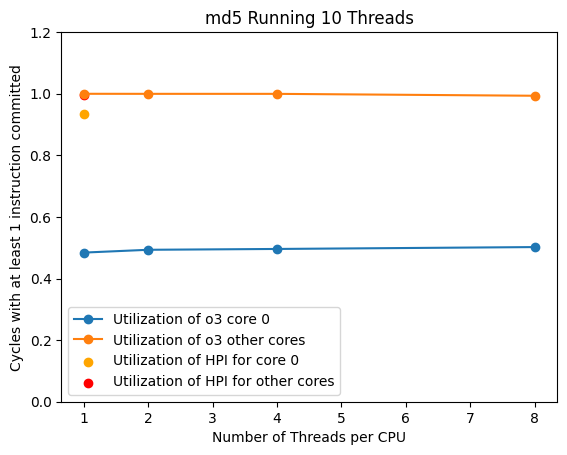

In [82]:
import matplotlib.pyplot as plt
import matplotlib

print(xpoints)
print(utilization0)

matplotlib.style.use('default')
plt.plot(xpoints, utilization0, label = "Utilization of o3 core 0",marker='o')
plt.plot(xpoints, utilizationnon0, label = "Utilization of o3 other cores",marker='o')
plt.scatter(1, hpi_utilizationCore0, label = "Utilization of HPI for core 0", color="orange")
plt.scatter(1, hpi_utilizationCoreNon0, label = "Utilization of HPI for other cores", color="red")
#plt.scatter(1, minor_utilization, label = "Utilization of minor", color="red")
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads per CPU")
plt.ylabel("Cycles with at least 1 instruction committed")
plt.ylim(ymin=0, ymax=1.2)
plt.legend()
plt.savefig('plots/utilization1.pdf')
print(hpi_utilizationCoreNon0)

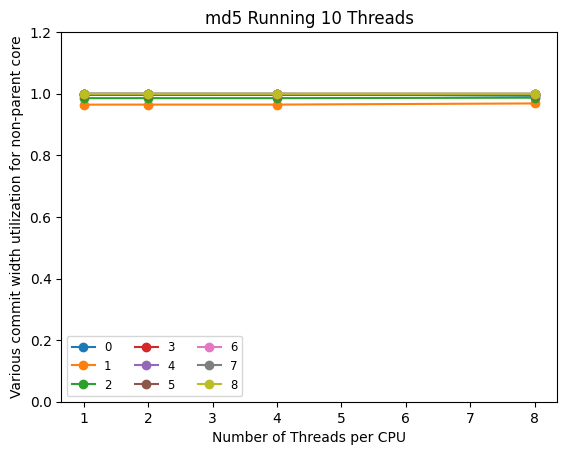

In [88]:
# Breakdown of commit utilization

matplotlib.style.use('default')
plt.plot(xpoints, utilizationnon0, label = "0",marker='o')
plt.plot(xpoints, utilizationnon1, label = "1",marker='o')
plt.plot(xpoints, utilizationnon2, label = "2",marker='o')
plt.plot(xpoints, utilizationnon3, label = "3",marker='o')
plt.plot(xpoints, utilizationnon4, label = "4",marker='o')
plt.plot(xpoints, utilizationnon5, label = "5",marker='o')
plt.plot(xpoints, utilizationnon6, label = "6",marker='o')
plt.plot(xpoints, utilizationnon7, label = "7",marker='o')
plt.plot(xpoints, utilizationnon8, label = "8",marker='o')
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads per CPU")
plt.ylabel("Various commit width utilization for non-parent core")
plt.ylim(ymin=0, ymax=1.2)
plt.legend(fontsize='small',ncol=3)
plt.savefig('plots/commit_change_child.jpg')

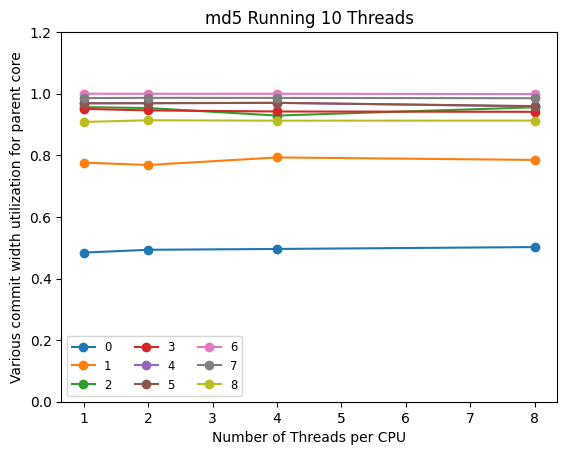

In [87]:
matplotlib.style.use('default')
plt.plot(xpoints, utilization0, label = "0",marker='o')
plt.plot(xpoints, utilization1, label = "1",marker='o')
plt.plot(xpoints, utilization2, label = "2",marker='o')
plt.plot(xpoints, utilization3, label = "3",marker='o')
plt.plot(xpoints, utilization4, label = "4",marker='o')
plt.plot(xpoints, utilization5, label = "5",marker='o')
plt.plot(xpoints, utilization6, label = "6",marker='o')
plt.plot(xpoints, utilization7, label = "7",marker='o')
plt.plot(xpoints, utilization8, label = "8",marker='o')
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads per CPU")
plt.ylabel("Various commit width utilization for parent core")
plt.ylim(ymin=0, ymax=1.2)
plt.legend(fontsize='small',ncol=3)
plt.savefig('plots/commit_change_parent.jpg')

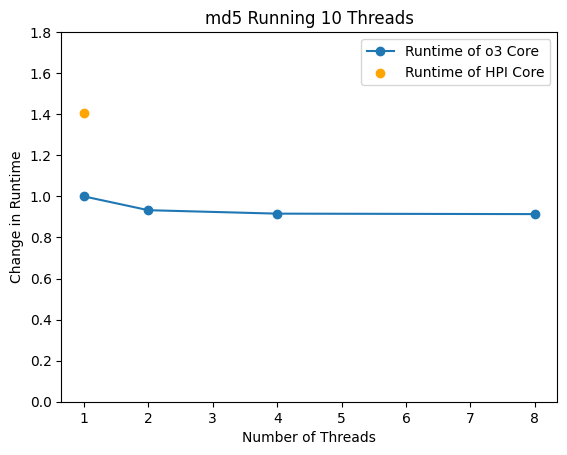

[4.95339575e+09 4.62028375e+09 4.53717375e+09 4.52599975e+09]
1.4075228594444529


In [80]:
import matplotlib.pyplot as plt

plt.plot(xpoints, numSecs/numSecs[0], label = "Runtime of o3 Core",marker='o')
plt.scatter(1, hpi_numSecs/numSecs[0], label = "Runtime of HPI Core", color="orange")
#plt.scatter(1, minor_numSecs/numSecs[0], label = "Runtime of minor Core", color="red")
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads")
plt.ylabel("Change in Runtime")
plt.ylim(ymin=0, ymax=1.8)
plt.legend()
plt.savefig("plots/Performance.jpg")
plt.show()
print(numSecs)
print(hpi_numSecs/numSecs[0])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


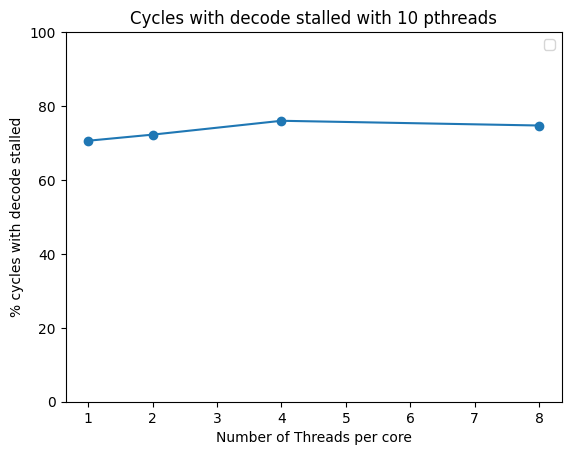

In [61]:
import matplotlib.pyplot as plt

# Plotting the area of 1 core
plt.plot(xpoints, decode_stallCycles, marker='o')

plt.ylim(ymin=0, ymax=100)
# Adding labels and title
plt.xlabel('Number of Threads per core')
plt.ylabel('% cycles with decode stalled')
plt.title('Cycles with decode stalled with 10 pthreads')

plt.savefig('plots/decode_stalled.jpg')
# Adding a legend
plt.legend()

# Show the plot
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


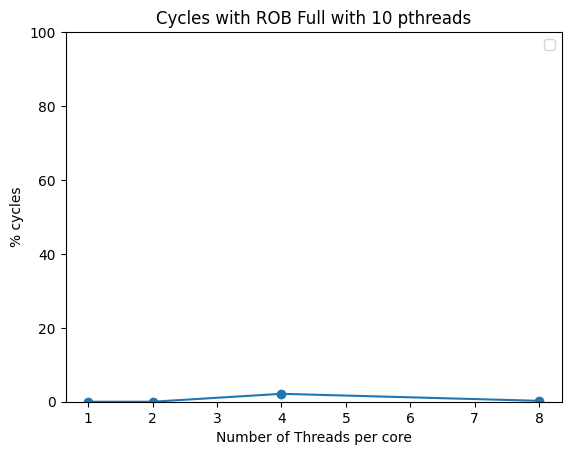

In [62]:
# Plotting the area of 1 core
plt.plot(xpoints, rename_perROBFull, marker='o')

plt.ylim(ymin=0, ymax=100)
# Adding labels and title
plt.xlabel('Number of Threads per core')
plt.ylabel('% cycles')
plt.title('Cycles with ROB Full with 10 pthreads')

plt.savefig('plots/ROBFull.jpg')
# Adding a legend
plt.legend()

# Show the plot
plt.show()

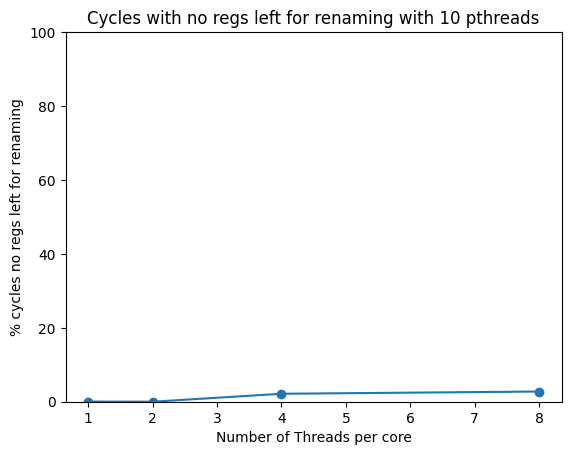

In [63]:
# Plotting the area of 1 core
plt.plot(xpoints, rename_perNoRegsLeft, marker='o')

plt.ylim(ymin=0, ymax=100)
# Adding labels and title
plt.xlabel('Number of Threads per core')
plt.ylabel('% cycles no regs left for renaming')
plt.title('Cycles with no regs left for renaming with 10 pthreads')

plt.savefig('plots/noRenamgeegs_stalled.jpg')

# Show the plot
plt.show()

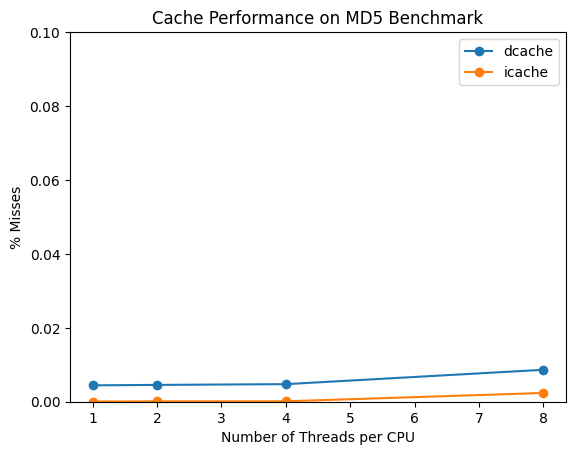

In [78]:
plt.ylim(ymin=0, ymax=0.1)
plt.plot(xpoints, (dcache_overallMisses), label = "dcache", marker='o')
plt.plot(xpoints, (icache_overallMisses), label = "icache", marker='o')
plt.title("Cache Performance on MD5 Benchmark")
plt.xlabel("Number of Threads per CPU")
plt.ylabel("% Misses")
plt.legend()
plt.savefig('plots/caches_fig.jpg')
plt.show()

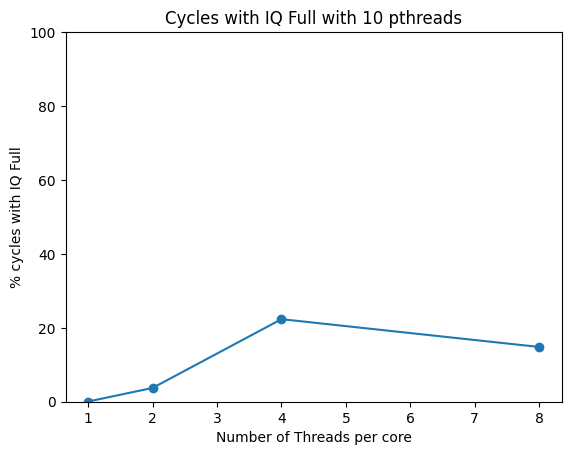

In [64]:

plt.plot(xpoints, iew_perIQFull, marker='o')

plt.ylim(ymin=0, ymax=100)
# Adding labels and title
plt.xlabel('Number of Threads per core')
plt.ylabel('% cycles with IQ Full')
plt.title('Cycles with IQ Full with 10 pthreads')

plt.savefig('plots/plotIQFull.jpg')

# Show the plot
plt.show()

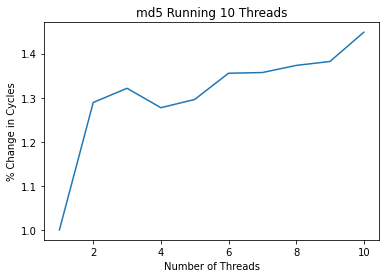

[5457813. 7036174. 7211796. 6971170. 7073335. 7398011. 7406568. 7494816.
 7543632. 7905662.]


In [ ]:
plt.plot(xpoints, numCycles/numCycles[0], label = "cycles")
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads")
plt.ylabel("% Change in Cycles")
plt.legend()
plt.show()
print(numCycles)

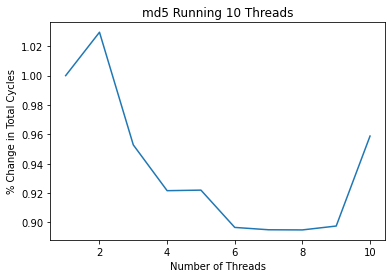

[10207780. 10509413.  9726066.  9407670.  9411466.  9152144.  9135846.
  9134794.  9161814.  9787454.]


In [ ]:
plt.plot(xpoints, totalNumCycles/totalNumCycles[0], label = "total cycles")
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads")
plt.ylabel("% Change in Total Cycles")
plt.legend()
plt.show()
print(totalNumCycles)

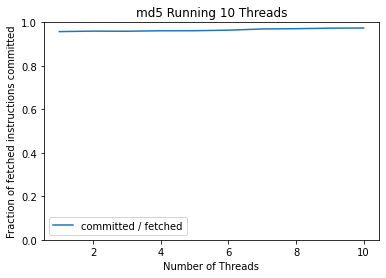

[0.95747144 0.95970771 0.95919096 0.96136679 0.96158351 0.96403842
 0.96953293 0.97092724 0.97322778 0.97405859]


In [ ]:
plt.plot(xpoints, instsEfficiency, label = "committed / fetched")
plt.title("md5 Running 10 Threads")
plt.xlabel("Number of Threads")
plt.ylabel("Fraction of fetched instructions committed")
plt.legend()
plt.ylim(ymin=0, ymax=1)
plt.show()
print(instsEfficiency)

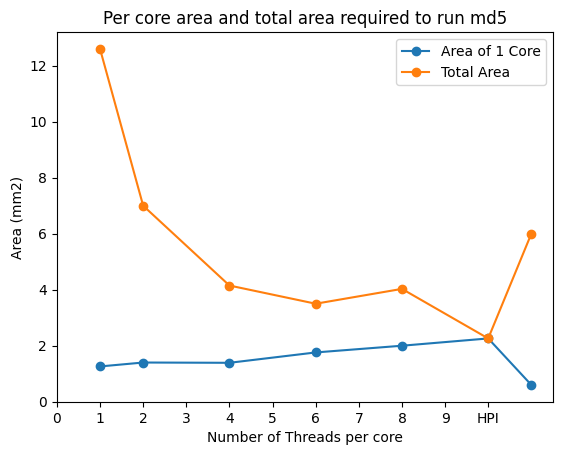

In [ ]:
import matplotlib.pyplot as plt

# Data
threads = [1, 2, 4, 6, 8, 10,11]  # Including 0 for HPI data
area_1_core = [1.26, 1.4, 1.39, 1.76, 2, 2.26,0.6]
total_area = [12.6, 7, 4.15, 3.5, 4.03, 2.26,6]

# Plotting the area of 1 core
plt.plot(threads, area_1_core, label='Area of 1 Core', marker='o')

# Plotting the total area
plt.plot(threads, total_area, label='Total Area', marker='o')


# Adding labels and title
plt.xlabel('Number of Threads per core')
plt.ylabel('Area (mm2)')
plt.title('Per core area and total area required to run md5')

# Set custom x-axis ticks
threads = [0,1,2,3,4,5,6,7,8,9]
custom_ticks = threads + ['HPI']
plt.xticks(range(len(custom_ticks)), custom_ticks)
plt.savefig('area.pdf')
# Adding a legend
plt.legend()

# Show the plot
plt.show()

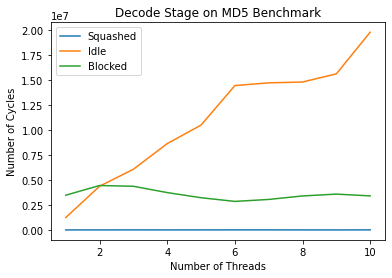

[ 1245344.  4373284.  6068087.  8627600. 10474774. 14419948. 14691277.
 14773684. 15587145. 19742906.]
[3475806. 4442028. 4364843. 3736361. 3222846. 2854685. 3051931. 3400752.
 3584232. 3404715.]
[ 9781.  9503. 11330.  9396. 10698. 13885. 13511.  9375.  9311. 10961.]


In [ ]:
plt.plot(xpoints, decode_squashCycles, label = "Squashed")
plt.plot(xpoints, decode_idleCycles, label = "Idle")
plt.plot(xpoints, decode_blockedCycles, label = "Blocked")
plt.title("Decode Stage on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Cycles")
plt.legend()
plt.savefig('graphs/decode.png')
plt.show()
print(decode_idleCycles)
print(decode_blockedCycles)
print(decode_squashCycles)

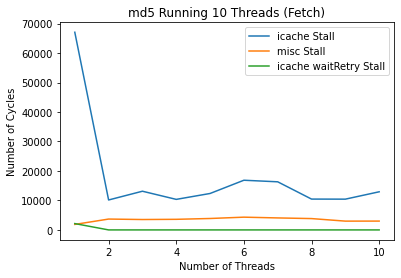

[67068. 10160. 13128. 10362. 12363. 16856. 16323. 10462. 10438. 12936.]
[1865. 3684. 3527. 3596. 3876. 4326. 4068. 3847. 2983. 2994.]
[2149.    0.    0.    0.    0.    0.    0.    0.    0.    0.]


In [ ]:
plt.plot(xpoints, fetch_icacheStallCycles, label = "icache Stall")
plt.plot(xpoints, fetch_miscStallCycles, label = "misc Stall")
plt.plot(xpoints, fetch_icacheWaitRetryStallCycles, label = "icache waitRetry Stall")
plt.title("md5 Running 10 Threads (Fetch)")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Cycles")
plt.legend()
plt.show()
print(fetch_icacheStallCycles)
print(fetch_miscStallCycles)
print(fetch_icacheWaitRetryStallCycles)

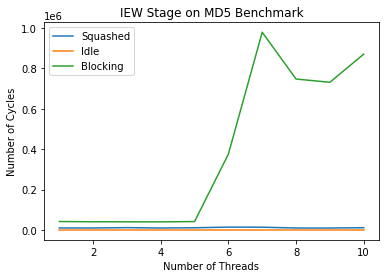

[ 9781.  9503. 11330.  9396. 10698. 13885. 13511.  9375.  9311. 10961.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 41592.  40324.  40137.  39793.  41429. 375397. 978932. 747288. 731086.
 870314.]


In [ ]:
plt.plot(xpoints, iew_squashCycles, label = "Squashed")
plt.plot(xpoints, iew_idleCycles, label = "Idle")
plt.plot(xpoints, iew_blockCycles, label = "Blocking")
plt.title("IEW Stage on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Cycles")
plt.legend()
plt.savefig('graphs/iew_fig.png')
plt.show()
print(iew_squashCycles)
print(iew_idleCycles)
print(iew_blockCycles)

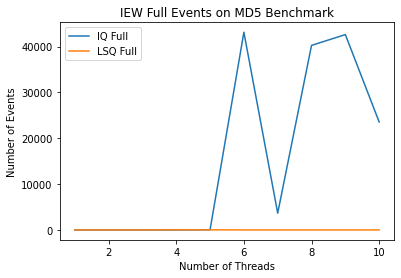

[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 3.6000e+01 4.3123e+04
 3.6590e+03 4.0256e+04 4.2609e+04 2.3550e+04]
[ 0.  0.  0. 27. 17.  0.  0.  0.  0.  0.]


In [ ]:
plt.plot(xpoints, iew_iqFullEvents, label = "IQ Full")
plt.plot(xpoints, iew_lsqFullEvents, label = "LSQ Full")
plt.title("IEW Full Events on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Events")
plt.legend()
plt.savefig('graphs/iew2_fig.png')
plt.show()
print(iew_iqFullEvents)
print(iew_lsqFullEvents)


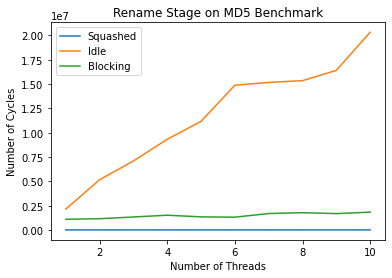

[ 9781.  9503. 11330.  9396. 10698. 13885. 13511.  9375.  9311. 10961.]
[ 2149142.  5168131.  7092936.  9320540. 11164013. 14873369. 15168130.
 15346171. 16403472. 20320758.]
[1102064. 1160387. 1337696. 1519108. 1349472. 1319871. 1693817. 1779545.
 1683928. 1835727.]


In [ ]:
plt.plot(xpoints, rename_squashCycles, label = "Squashed")
plt.plot(xpoints, rename_idleCycles, label = "Idle")
plt.plot(xpoints, rename_blockCycles, label = "Blocking")
plt.title("Rename Stage on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Cycles")
plt.legend()
plt.savefig('graphs/rename_fig.png')
plt.show()
print(rename_squashCycles)
print(rename_idleCycles)
print(rename_blockCycles)

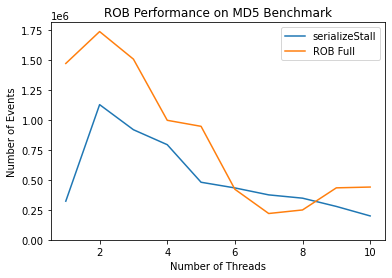

[ 321704. 1125899.  916945.  792292.  479401.  432167.  374240.  346799.
  277939.  198785.]
[1468899. 1734483. 1504818.  995419.  945203.  420866.  219044.  248618.
  432785.  439400.]


In [ ]:
plt.plot(xpoints, rename_serializeStallCycles, label = "serializeStall")
plt.plot(xpoints, rename_ROBFullEvents, label = "ROB Full")
plt.title("ROB Performance on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Events")
plt.ylim(ymin=0)
plt.legend()
plt.savefig('graphs/rob_fig.png')
plt.show()
print(rename_serializeStallCycles)
print(rename_ROBFullEvents)

In [ ]:
import numpy as np
import re

iterations = 10

#General:
xpoints = np.arange(iterations) + 1
rename_ROBFullEvents_2x = np.zeros(iterations)
rename_ROBFullEvents_halfx = np.zeros(iterations)

for t in range(iterations):  
    threads = t+1  
    filename = "stats/OutputStats_ROB_2x_" + str(threads)
    stats = open(filename)
    for line in stats:
        if ".rename.ROBFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_ROBFullEvents_2x[t] += float(match.group())
    
    filename = "stats/OutputStats_ROB_halfx_" + str(threads)
    stats = open(filename)
    for line in stats:
        if ".rename.ROBFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_ROBFullEvents_halfx[t] += float(match.group())

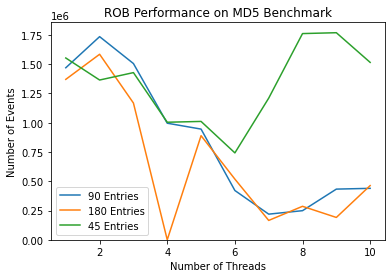

[1468899. 1734483. 1504818.  995419.  945203.  420866.  219044.  248618.
  432785.  439400.]
[1369777. 1584020. 1167736.       0.  888944.  518088.  165425.  285928.
  190822.  462905.]
[1552244. 1364166. 1427456. 1003722. 1010702.  741996. 1209465. 1760680.
 1768059. 1514679.]


In [ ]:
plt.plot(xpoints, rename_ROBFullEvents, label = "90 Entries")
plt.plot(xpoints, rename_ROBFullEvents_2x, label = "180 Entries")
plt.plot(xpoints, rename_ROBFullEvents_halfx, label = "45 Entries")
plt.title("ROB Performance on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Events")
plt.ylim(ymin=0)
plt.legend()
plt.savefig('graphs/rob_fig_scaled.png')
plt.show()
print(rename_ROBFullEvents)
print(rename_ROBFullEvents_2x)
print(rename_ROBFullEvents_halfx)

In [ ]:
import numpy as np
import re

iterations = 10

#General:
xpoints = np.arange(iterations) + 1
iew_iqFullEvents_2x = np.zeros(iterations)
iew_iqFullEvents_4x = np.zeros(iterations)

rename_ROBFullEvents_2x = np.zeros(iterations)
rename_ROBFullEvents_4x = np.zeros(iterations)

for t in range(iterations):  
    threads = t+1  
    filename = "stats/OutputStats_IQ_2x_" + str(threads)
    stats = open(filename)
    for line in stats:
        if ".iew.iqFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_iqFullEvents_2x[t] += float(match.group())
        if ".rename.ROBFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_ROBFullEvents_2x[t] += float(match.group())
    
    filename = "stats/OutputStats_IQ_4x_" + str(threads)
    stats = open(filename)
    for line in stats:
        if ".iew.iqFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                iew_iqFullEvents_4x[t] += float(match.group())
        if ".rename.ROBFullEvents" in line:
            match = re.search(r'\b\d+\b', line)
            if match:
                rename_ROBFullEvents_4x[t] += float(match.group())

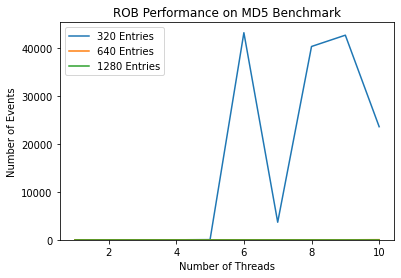

[0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 3.6000e+01 4.3123e+04
 3.6590e+03 4.0256e+04 4.2609e+04 2.3550e+04]
[ 0.  0.  0.  0.  0.  0.  0.  0.  0. 27.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [ ]:
plt.plot(xpoints, iew_iqFullEvents, label = "320 Entries")
plt.plot(xpoints, iew_iqFullEvents_2x, label = "640 Entries")
plt.plot(xpoints, iew_iqFullEvents_4x, label = "1280 Entries")
plt.title("IQ Performance on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Events")
plt.ylim(ymin=0)
plt.legend()
plt.savefig('graphs/iq_fig_scaled.png')
plt.show()
print(iew_iqFullEvents)
print(iew_iqFullEvents_2x)
print(iew_iqFullEvents_4x)

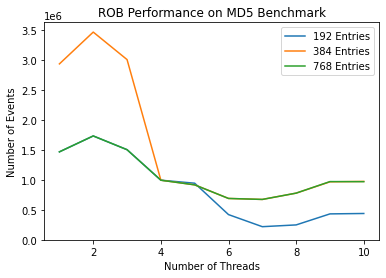

[1468899. 1734483. 1504818.  995419.  945203.  420866.  219044.  248618.
  432785.  439400.]
[2937798. 3468966. 3009636.  995420.  917711.  690620.  674202.  779419.
  968213.  974829.]
[1468899. 1734483. 1504818.  995420.  917711.  690620.  674202.  779420.
  972279.  970871.]


In [ ]:
import matplotlib.pyplot as plt

plt.plot(xpoints, rename_ROBFullEvents, label = "192 Entries")
plt.plot(xpoints, rename_ROBFullEvents_2x, label = "384 Entries")
plt.plot(xpoints, rename_ROBFullEvents_4x, label = "768 Entries")
plt.title("ROB Performance on MD5 Benchmark")
plt.xlabel("Number of Threads")
plt.ylabel("Number of Events")
plt.ylim(ymin=0)
plt.legend()
plt.savefig('graphs/rob_fig_scaled.png')
plt.show()
print(rename_ROBFullEvents)
print(rename_ROBFullEvents_2x)
print(rename_ROBFullEvents_4x)